# 02 Baseline Logistic Regression

First pass baseline. Keep preprocessing simple and check ranking + threshold metrics before trying stronger models.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme
from src.fraud_detection.metrics import build_curve_frames
from src.fraud_detection.train import fit_baseline_experiment

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 50_000
MISSING_THRESHOLD = 0.95
RANDOM_STATE = 42


In [2]:
# Fit the reusable baseline pipeline and keep the validation scores for plots.
experiment = fit_baseline_experiment(
    sample_size=SAMPLE_SIZE,
    missing_threshold=MISSING_THRESHOLD,
    random_state=RANDOM_STATE,
)

metrics = experiment["metrics"]
threshold_table = experiment["threshold_table"].copy()
curve_frames = build_curve_frames(experiment["y_valid"], experiment["validation_scores"])
best_f1_row = threshold_table.sort_values("f1", ascending=False).iloc[0]

y_valid = np.asarray(experiment["y_valid"])
validation_scores = np.asarray(experiment["validation_scores"])
y_pred_default = (validation_scores >= 0.5).astype(int)
cm = confusion_matrix(y_valid, y_pred_default, labels=[0, 1], normalize="true")

score_frame = pd.DataFrame(
    {
        "score": validation_scores,
        "Class": np.where(y_valid == 1, "fraud", "legit"),
    }
)

run_summary = pd.DataFrame(
    [
        ["sample_size", SAMPLE_SIZE],
        ["train_rows", len(experiment["x_train"])],
        ["validation_rows", len(experiment["x_valid"])],
        ["dropped_high_missing_columns", len(experiment["dropped_high_missing_columns"])],
        ["numeric_features", len(experiment["numeric_features"])],
        ["categorical_features", len(experiment["categorical_features"])],
    ],
    columns=["item", "value"],
)

core_metrics = pd.DataFrame(
    [
        ["accuracy", metrics["accuracy"]],
        ["roc_auc", metrics["roc_auc"]],
        ["average_precision", metrics["average_precision"]],
        ["precision_at_0_50", metrics["precision"]],
        ["recall_at_0_50", metrics["recall"]],
        ["f1_at_0_50", metrics["f1"]],
        ["balanced_accuracy_at_0_50", metrics["balanced_accuracy"]],
        ["precision_at_top_1pct", metrics["precision_at_top_1pct"]],
        ["recall_at_top_1pct", metrics["recall_at_top_1pct"]],
        ["precision_at_top_5pct", metrics["precision_at_top_5pct"]],
        ["recall_at_top_5pct", metrics["recall_at_top_5pct"]],
    ],
    columns=["metric", "value"],
)

print("done")
print(f"accuracy: {metrics['accuracy']:.4f}")
print(f"roc_auc: {metrics['roc_auc']:.4f}")
print(f"average_precision: {metrics['average_precision']:.4f}")


done
accuracy: 0.8527
roc_auc: 0.8245
average_precision: 0.3998


## Run Summary


In [3]:
display(run_summary.style.format({"value": "{:,}"}).hide(axis="index"))
display(core_metrics.style.format({"value": "{:.4f}"}).hide(axis="index"))

top_risk_table = pd.DataFrame(
    [
        ["top_1pct", metrics["precision_at_top_1pct"], metrics["recall_at_top_1pct"], metrics["lift_at_top_1pct"]],
        ["top_5pct", metrics["precision_at_top_5pct"], metrics["recall_at_top_5pct"], metrics["lift_at_top_5pct"]],
    ],
    columns=["slice", "precision", "recall", "lift"],
)
display(top_risk_table.style.format({"precision": "{:.2%}", "recall": "{:.2%}", "lift": "{:.2f}x"}).hide(axis="index"))


item,value
sample_size,"50,000"
train_rows,"40,000"
validation_rows,"10,000"
dropped_high_missing_columns,9
numeric_features,394
categorical_features,29


metric,value
accuracy,0.8527
roc_auc,0.8245
average_precision,0.3998
precision_at_0_50,0.1519
recall_at_0_50,0.6769
f1_at_0_50,0.2481
balanced_accuracy_at_0_50,0.7681
precision_at_top_1pct,0.7400
recall_at_top_1pct,0.2061
precision_at_top_5pct,0.3280


slice,precision,recall,lift
top_1pct,74.00%,20.61%,20.61x
top_5pct,32.80%,45.68%,9.14x


## Curves


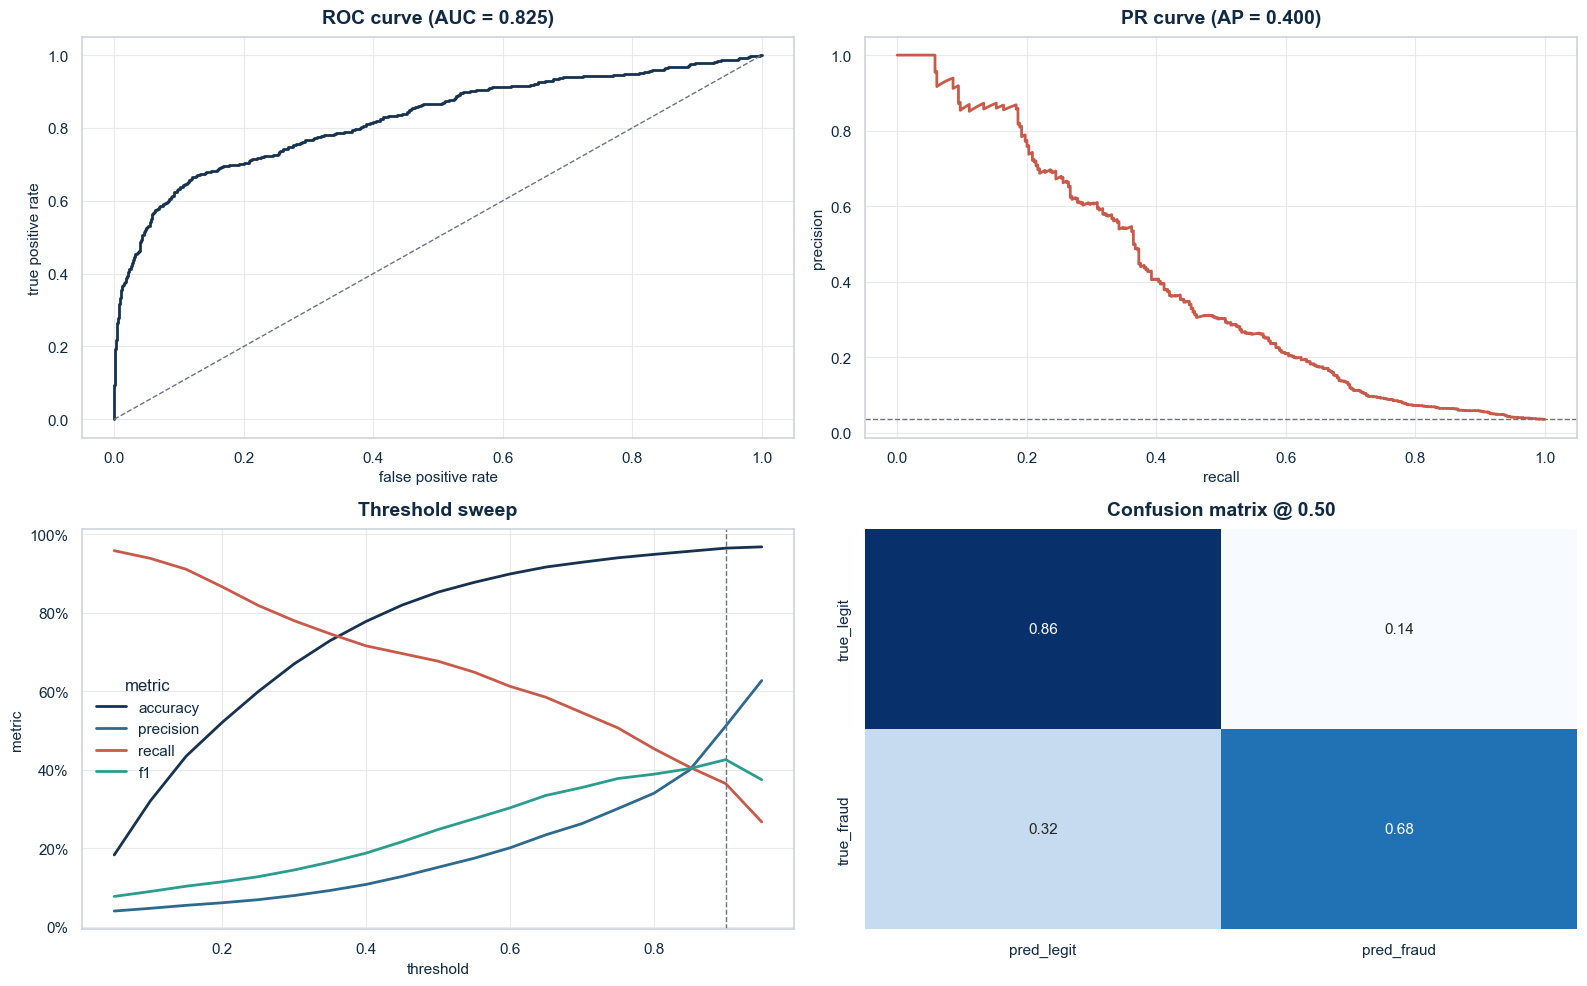

In [4]:
threshold_plot = threshold_table.melt(
    id_vars="threshold",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(curve_frames["roc"]["fpr"], curve_frames["roc"]["tpr"], color=PLOT_COLORS["navy"], linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[0, 0].set_title(f"ROC curve (AUC = {metrics['roc_auc']:.3f})")
axes[0, 0].set_xlabel("false positive rate")
axes[0, 0].set_ylabel("true positive rate")

axes[0, 1].plot(curve_frames["pr"]["recall"], curve_frames["pr"]["precision"], color=PLOT_COLORS["coral"], linewidth=2)
axes[0, 1].axhline(metrics["base_fraud_rate"], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[0, 1].set_title(f"PR curve (AP = {metrics['average_precision']:.3f})")
axes[0, 1].set_xlabel("recall")
axes[0, 1].set_ylabel("precision")

sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="value",
    hue="metric",
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["blue"], PLOT_COLORS["coral"], PLOT_COLORS["teal"]],
    linewidth=2,
    ax=axes[1, 0],
)
axes[1, 0].axvline(best_f1_row["threshold"], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[1, 0].set_title("Threshold sweep")
axes[1, 0].set_xlabel("threshold")
axes[1, 0].set_ylabel("metric")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    xticklabels=["pred_legit", "pred_fraud"],
    yticklabels=["true_legit", "true_fraud"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Confusion matrix @ 0.50")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()


## Score Distribution


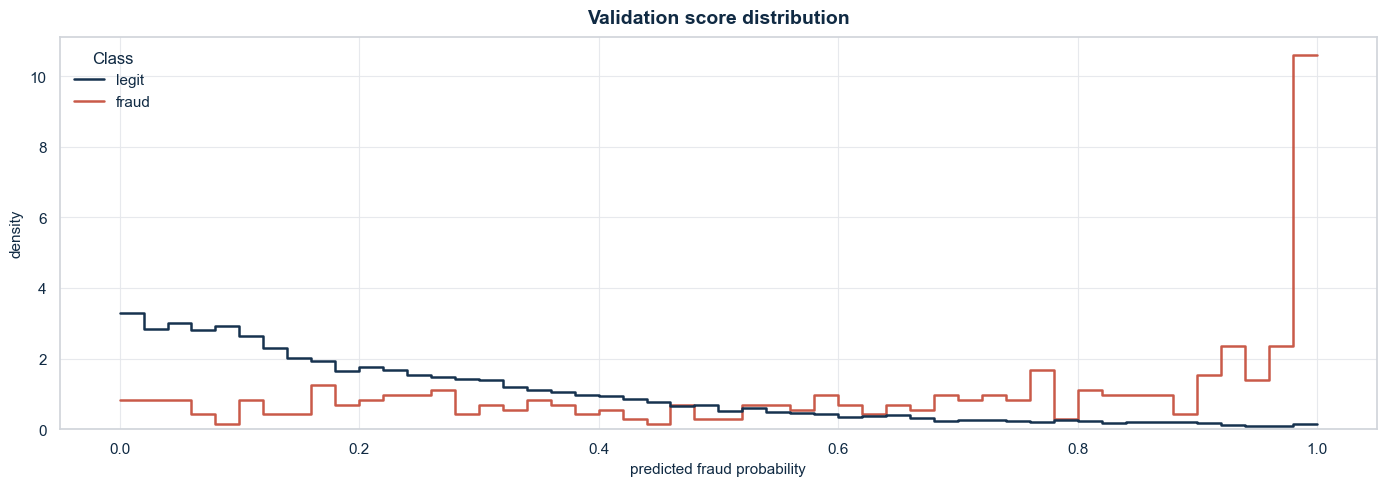

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(
    data=score_frame,
    x="score",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
    ax=ax,
)
ax.set_title("Validation score distribution")
ax.set_xlabel("predicted fraud probability")
ax.set_ylabel("density")
plt.tight_layout()
plt.show()


## Threshold Table


In [6]:
display(
    threshold_table.style.format(
        {
            "threshold": "{:.2f}",
            "accuracy": "{:.4f}",
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
            "log_loss": "{:.4f}",
            "brier_score": "{:.4f}",
            "precision": "{:.2%}",
            "recall": "{:.2%}",
            "f1": "{:.2%}",
            "balanced_accuracy": "{:.2%}",
            "positive_prediction_rate": "{:.2%}",
            "base_fraud_rate": "{:.2%}",
        }
    ).hide(axis="index")
)


threshold,roc_auc,average_precision,log_loss,brier_score,accuracy,precision,recall,f1,balanced_accuracy,positive_prediction_rate,base_fraud_rate
0.05,0.8245,0.3998,0.3926,0.1177,0.1834,4.05%,95.82%,7.77%,55.64%,84.95%,3.59%
0.10,0.8245,0.3998,0.3926,0.1177,0.3205,4.74%,93.87%,9.02%,61.81%,71.10%,3.59%
0.15,0.8245,0.3998,0.3926,0.1177,0.4350,5.50%,91.09%,10.37%,66.41%,59.45%,3.59%
0.20,0.8245,0.3998,0.3926,0.1177,0.5209,6.15%,86.63%,11.49%,68.72%,50.54%,3.59%
0.25,0.8245,0.3998,0.3926,0.1177,0.5992,6.94%,81.89%,12.79%,70.50%,42.37%,3.59%
0.30,0.8245,0.3998,0.3926,0.1177,0.6699,8.00%,77.99%,14.50%,72.29%,35.02%,3.59%
0.35,0.8245,0.3998,0.3926,0.1177,0.7291,9.29%,74.65%,16.52%,73.75%,28.86%,3.59%
0.40,0.8245,0.3998,0.3926,0.1177,0.7781,10.83%,71.59%,18.81%,74.81%,23.74%,3.59%
0.45,0.8245,0.3998,0.3926,0.1177,0.8196,12.85%,69.64%,21.70%,76.03%,19.45%,3.59%
0.50,0.8245,0.3998,0.3926,0.1177,0.8527,15.19%,67.69%,24.81%,76.81%,16.00%,3.59%
